<a href="https://colab.research.google.com/github/e23281-lgtm/Statistical-Learning-e23281/blob/main/Copy_of_Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

ANSWERS

---



#1.
Given the state transition equation:
$$x_k^- = A_{k-1} x_{k-1}^+ + G_{k-1} w_{k-1}$$

Since $x_{k-1}^+ \sim \mathcal{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathcal{N}(0, \Sigma_p)$ are independent Gaussian random variables, their linear combination is also Gaussian.

* **Mean ($m_k^-$):**
  $$m_k^- = \mathbb{E}[x_k^-] = \mathbb{E}[A_{k-1} x_{k-1}^+ + G_{k-1} w_{k-1}] = A_{k-1}\mathbb{E}[x_{k-1}^+] + G_{k-1}\mathbb{E}[w_{k-1}]$$
  $$m_k^- = A_{k-1}m_{k-1} + 0 = A_{k-1}m_{k-1}$$

* **Covariance ($P_k^-$):**
  $$P_k^- = \text{Var}(x_k^-) = \text{Var}(A_{k-1} x_{k-1}^+ + G_{k-1} w_{k-1})$$
  Since $x_{k-1}^+$ and $w_{k-1}$ are independent:
  $$P_k^- = A_{k-1}\text{Var}(x_{k-1}^+)A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$
  $$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$


#2.


Given the measurement equation:
$$y_k^- = H_k x_k^- + z_k$$
where $z_k \sim \mathcal{N}(0, \Sigma_m)$ is independent of $x_k^-$.

* **Mean:**
  $$\mathbb{E}[y_k^-] = \mathbb{E}[H_k x_k^- + z_k] = H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^-$$

* **Covariance:**
  $$\text{Var}(y_k^-) = \text{Var}(H_k x_k^- + z_k) = H_k \text{Var}(x_k^-)H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$

#3.

The joint distribution of two Gaussian vectors is completely specified by their individual means, variances, and their cross-covariance:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T\right]$$

Substitute $y_k^- - H_k m_k^- = H_k(x_k^- - m_k^-) + z_k$:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T\right]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)(x_k^- - m_k^-)^T H_k^T\right] + \mathbb{E}\left[(x_k^- - m_k^-)z_k^T\right]$$

Since $x_k^-$ and $z_k$ are independent, the cross term is zero:
$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T$$

By symmetry, $\text{Cov}(y_k^-, x_k^-) = H_k P_k^-$. Stacking these yields the block joint distribution matrix:
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix} \right)$$


#4.

Using the standard Gaussian conditioning property for a joint system:
$$\mathbb{E}[X \mid Y=y] = \mu_x + \Sigma_{xy}\Sigma_{yy}^{-1}(y - \mu_y)$$
$$\text{Var}(X \mid Y=y) = \Sigma_{xx} - \Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}$$

Substituting our joint matrix elements:
$$K_k = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$
$$m_k = m_k^- + K_k(y_k^{\text{obs}} - H_k m_k^-)$$
$$P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k)P_k^-$$

#5.
By direct definition of the conditional state distribution vector parameters evaluated above:
* $\mathbb{E}[x_k^- \mid y_k^- = y_k^{\text{obs}}] = m_k$
* $\text{Var}(x_k^- \mid y_k^- = y_k^{\text{obs}}) = P_k$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

#1.

For a 1-D scalar system, the matrix parameters simplify to single values:
$A_{k-1} = a$, $G_{k-1} = 1$, and $\Sigma_p = q$.

Substituting these into the general matrix tracking equations derived in Section 1:
* **Prior Mean:**
  $$m_k^- = A_{k-1} m_{k-1} \implies m_k^- = a m_{k-1}$$
* **Prior Covariance:**
  $$P_k^- = A_{k-1} P_{k-1} A_{k-1}^T + G_{k-1} \Sigma_p G_{k-1}^T \implies P_k^- = a(P_{k-1})a + 1(q)1 = a^2 P_{k-1} + q$$

#2.

For the observation update components, the scalar equivalents are $H_k = h$ and $\Sigma_m = r$.

* **Kalman Gain ($K_k$):**
  $$K_k = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1} \implies K_k = \frac{P_k^- h}{h^2 P_k^- + r}$$

* **Posterior Mean ($m_k$):**
  $$m_k = m_k^- + K_k(y_k^{\text{obs}} - H_k m_k^-) \implies m_k = m_k^- + K_k(y_k^{\text{obs}} - h m_k^-)$$

* **Posterior Covariance ($P_k$):**
  $$P_k = (1 - K_k H_k)P_k^- \implies P_k = (1 - K_k h)P_k^-$$

Substituting the scalar expression for $K_k$ into the equation yields:
$$P_k = \left(1 - \frac{P_k^- h^2}{h^2 P_k^- + r}\right)P_k^-$$

#3 & 4.
* **3. Predictive Measurement Distribution (Before seeing $y_k$):**
  $$p(y_k^- \mid Y_{k-1}) = \mathcal{N}(h m_k^-, h^2 P_k^- + r)$$
  *(Derived by substituting the 1-D parameters directly into the mean $H_k m_k^-$ and variance $H_k P_k^- H_k^T + \Sigma_m$ components found in Section 1, Part 2).*

* **4. Posterior-Predictive Measurement Distribution (After filtering on $y_k$):**
  $$p(y_k^- \mid Y_k) = \mathcal{N}(h m_k, h^2 P_k + r)$$
  *(Derived by mapping the measurement vector transformation over the updated state vector estimate $x_k^+ \sim \mathcal{N}(m_k, P_k)$).*

#5.

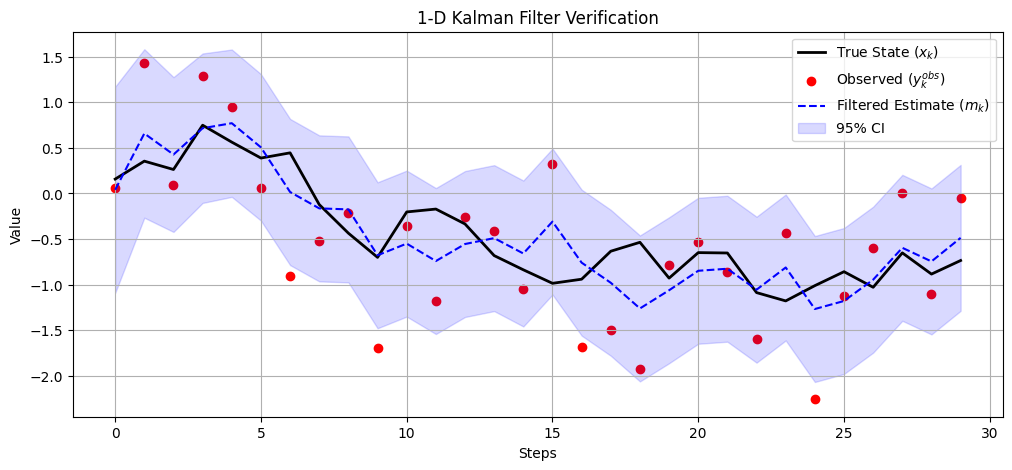

In [ ]:
# 1-D Kalman Filter Implementation and Simulation
import numpy as np
import matplotlib.pyplot as plt

# Given Model Parameters
a, h, q, r = 0.95, 1.0, 0.1, 0.5
n_steps = 30

np.random.seed(42)
x_true = 0.0
m = 0.0
P = 1.0

true_states = []
measurements = []
means_post = []
vars_post = []

for k in range(n_steps):
    # Process updates (True State generation)
    w = np.random.normal(0, np.sqrt(q))
    x_true = a * x_true + w
    true_states.append(x_true)

    # Measurement generation (Observation)
    z = np.random.normal(0, np.sqrt(r))
    y_obs = h * x_true + z
    measurements.append(y_obs)

    # Time Update (Predict)
    m_minus = a * m
    P_minus = (a**2) * P + q

    # Measurement Update (Correct)
    K = (P_minus * h) / (h**2 * P_minus + r)
    m = m_minus + K * (y_obs - h * m_minus)
    P = (1 - K * h) * P_minus

    means_post.append(m)
    vars_post.append(P)

# Plotting Results
plt.figure(figsize=(12, 5))
plt.plot(true_states, label='True State ($x_k$)', color='black', lw=2)
plt.scatter(range(n_steps), measurements, label='Observed ($y_k^{obs}$)', color='red')
plt.plot(means_post, label='Filtered Estimate ($m_k$)', color='blue', linestyle='--')
plt.fill_between(range(n_steps), np.array(means_post) - 1.96*np.sqrt(vars_post),
                 np.array(means_post) + 1.96*np.sqrt(vars_post), color='blue', alpha=0.15, label='95% CI')
plt.title('1-D Kalman Filter Verification')
plt.xlabel('Steps')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$


### Part A:
By kinematics, position coordinates change based on current velocity parameters during interval time $\Delta t$:
$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x\Delta t^2$$
$$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}a_y\Delta t^2$$

Velocities accelerate based directly on the noise inputs:
$$v_x(k) = v_x(k-1) + a_x\Delta t$$
$$v_y(k) = v_y(k-1) + a_y\Delta t$$

Putting these structural dynamics into vector equations perfectly isolates the matrices shown in the problem:
$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \quad G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

Because the observation vector only tracks positions $p_x$ and $p_y$, the mapping matrix $H$ strictly strips out the last two velocity coordinates:
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$




## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

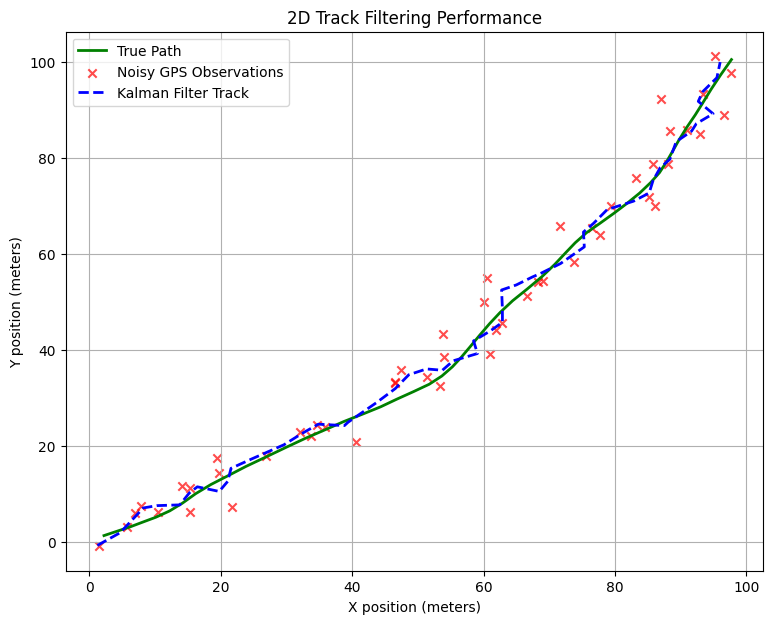

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

dt = 1.0
n_samples = 50

A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1,  0],
              [0, 0, 0,  1]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

G = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])

Sigma_p = np.eye(2) * 0.1   # Process noise
Sigma_m = np.eye(2) * 5.0   # Measurement noise (Noisy GPS variance)

np.random.seed(24)
x_true = np.array([0.0, 0.0, 2.0, 1.5])
true_trajectory = []
gps_measurements = []

for _ in range(n_samples):
    w = np.random.multivariate_normal([0, 0], Sigma_p)
    x_true = A @ x_true + G @ w
    true_trajectory.append(x_true.copy())

    z = np.random.multivariate_normal([0, 0], Sigma_m)
    y_obs = H @ x_true + z
    gps_measurements.append(y_obs)

true_trajectory = np.array(true_trajectory)
gps_measurements = np.array(gps_measurements)

# Kalman Filter Algorithm Loop
m = np.array([0.0, 0.0, 0.0, 0.0])
P = np.eye(4) * 10.0
filtered_states = []

for k in range(n_samples):
    # Predict Step
    m_minus = A @ m
    P_minus = A @ P @ A.T + G @ Sigma_p @ G.T

    # Update Step
    y_obs = gps_measurements[k]
    S = H @ P_minus @ H.T + Sigma_m
    K = P_minus @ H.T @ np.linalg.inv(S)

    m = m_minus + K @ (y_obs - H @ m_minus)
    P = (np.eye(4) - K @ H) @ P_minus
    filtered_states.append(m.copy())

filtered_states = np.array(filtered_states)

# Generate Plot
plt.figure(figsize=(9, 7))
plt.plot(true_trajectory[:, 0], true_trajectory[:, 1], 'g-', label='True Path', lw=2)
plt.scatter(gps_measurements[:, 0], gps_measurements[:, 1], color='red', marker='x', alpha=0.7, label='Noisy GPS Observations')
plt.plot(filtered_states[:, 0], filtered_states[:, 1], 'b--', label='Kalman Filter Track', lw=2)
plt.xlabel('X position (meters)')
plt.ylabel('Y position (meters)')
plt.title('2D Track Filtering Performance')
plt.legend()
plt.grid(True)
plt.show()